# 🇪🇬 Egyptian Used Car Price Prediction Using Machine Learning

## 📌 Project Overview

The used car market in Egypt is dynamic, with vehicle prices influenced by multiple factors such as brand, model, manufacturing year, mileage, location, and vehicle condition. Estimating a fair selling price can be challenging for both buyers and sellers due to market fluctuations and the large variety of available vehicles.

In this project, we develop a machine learning regression model capable of predicting the market price of used cars listed on Hatla2ee, one of Egypt's largest online automotive marketplaces.

The project follows a complete end-to-end machine learning workflow, including:

- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Model Training
- Hyperparameter Tuning
- Model Explainability using SHAP
- Streamlit Deployment

The final model can estimate the selling price of a used vehicle based on its characteristics, providing valuable insights for buyers, sellers, and automotive businesses.

# 🎯 Business Problem

Determining the appropriate selling price for a used car is often difficult because many vehicle characteristics influence its value.

This project aims to answer the following questions:

- Which factors have the greatest impact on used car prices?
- How accurately can machine learning estimate vehicle prices?
- Which regression algorithm performs best for this problem?
- How can explainable AI help us understand model predictions?

The objective is to build a reliable regression model that predicts the market value of used vehicles in Egypt.

# 📂 Dataset Description

Source:
Hatla2ee (Egyptian Used Car Marketplace)

Dataset Size:
- 24,688 vehicle listings

Target Variable:
- Price (EGP)

Features include:

- Company
- Model
- Manufacturing Year
- Mileage
- Color
- Location
- Date Posted
- Vehicle Features
- Listing Title

The dataset represents real-world used car advertisements collected during August 2025.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [3]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Asus\OneDrive\Desktop\ML_WORK\Used_Car_Price_Prediction\data\used_cars\hatla2ee_cars_august_2025.csv"
)

In [4]:
# Preserve the original transmission values before any cleaning or filtering
df["transmission_raw"] = (
    df["transmission"]
    .astype("string")
    .str.strip()
    .str.title()
)

df["transmission_raw"].value_counts(dropna=False)


transmission_raw
<NA>         24381
Automatic      195
Manual         112
Name: count, dtype: Int64

In [5]:
df.shape

(24688, 13)

In [6]:
df.head()

,title,company,model,year,price,mileage,color,transmission,location,date_posted,features,detail_link,transmission_raw
0,Volkswagen Tiguan 2018,Volkswagen,Tiguan,2018.0,"1,640,000 EGP","58,000 Km",Dark blue,NaN,Alexandria,2025-08-07,NaN,https://eg.hatla2ee.com/en/car/volks-wagen/tig...,<NA>
1,BMW X6 M 2019,BMW,X6,2019.0,"3,650,000 EGP","80,000 Km",Silver,NaN,Port Said,2025-08-07,Automatic | Air Conditioner,https://eg.hatla2ee.com/en/car/bmw/X6-M/7032781,<NA>
2,MG ZS 2021,MG,ZS,2021.0,"800,000 EGP","100,000 Km",Silver,NaN,Luxor,2025-08-07,Automatic | Air Conditioner | Power Steering |...,https://eg.hatla2ee.com/en/car/moris-garage/zs...,<NA>
3,Chevrolet Optra 2005,Chevrolet,Optra,2005.0,"360,000 EGP","270,000 Km",White,NaN,6 October,2025-08-07,Automatic | Air Conditioner | Remote Control,https://eg.hatla2ee.com/en/car/chevrolet/optra...,<NA>
4,Peugeot 3008 2021,Peugeot,3008,3008.0,"1,850,000 EGP","20,000 Km",Red,NaN,6 October,2025-08-07,Automatic | Air Conditioner | Power Steering |...,https://eg.hatla2ee.com/en/car/peugeot/3008/70...,<NA>


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24688 entries, 0 to 24687
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             24688 non-null  object 
 1   company           24688 non-null  object 
 2   model             24688 non-null  object 
 3   year              24682 non-null  float64
 4   price             24688 non-null  object 
 5   mileage           23278 non-null  object 
 6   color             24688 non-null  object 
 7   transmission      307 non-null    object 
 8   location          24688 non-null  object 
 9   date_posted       24688 non-null  object 
 10  features          16870 non-null  object 
 11  detail_link       24688 non-null  object 
 12  transmission_raw  307 non-null    string 
dtypes: float64(1), object(11), string(1)
memory usage: 2.4+ MB


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,24688,4282,Mitsubishi Lancer EX Shark 2016,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,24688,106,Hyundai,2618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,24688,699,Lancer,719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,24682.0,NaN,NaN,NaN,2029.546917,186.663631,1100.0,2008.0,2015.0,2020.0,5008.0
price,24688,910,"650,000 EGP",514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,23278,1381,"200,000 Km",970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,24688,25,Silver,4988,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,307,3,Automatic,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,24688,177,Cairo,3499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_posted,24688,103,2025-08-07,932,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df["price"].head(10)

0    1,640,000 EGP
1    3,650,000 EGP
2      800,000 EGP
3      360,000 EGP
4    1,850,000 EGP
5      480,000 EGP
6      660,000 EGP
7      580,000 EGP
8    2,650,000 EGP
9    1,300,000 EGP
Name: price, dtype: object

In [10]:
df["price"].sample(10)

12510    1,470,000 EGP
24246    2,600,000 EGP
10677      330,000 EGP
8388     1,200,000 EGP
2827       495,000 EGP
9751       160,000 EGP
7708       975,000 EGP
9110       360,000 EGP
13678      345,000 EGP
24477      680,000 EGP
Name: price, dtype: object

In [11]:
df["mileage"].head(10)

0     58,000 Km
1     80,000 Km
2    100,000 Km
3    270,000 Km
4     20,000 Km
5    250,000 Km
6    110,000 Km
7    120,000 Km
8      4,800 Km
9    139,000 Km
Name: mileage, dtype: object

In [12]:
df["transmission"].value_counts(dropna=False)

transmission
NaN          24381
Automatic      195
Manual         111
manual           1
Name: count, dtype: int64

In [13]:
df["detail_link"].iloc[0]

'https://eg.hatla2ee.com/en/car/volks-wagen/tiguan/7030177'

In [14]:
df["year"].sort_values().head(20)

176      1100.0
11978    1100.0
20495    1100.0
18821    1200.0
8984     1200.0
3363     1200.0
10908    1300.0
11658    1500.0
16554    1500.0
23824    1500.0
16263    1500.0
5073     1972.0
20984    1972.0
21139    1973.0
3028     1974.0
11000    1974.0
12724    1975.0
20261    1975.0
18649    1975.0
12321    1975.0
Name: year, dtype: float64

In [15]:
df["year"].sort_values().tail(20)

19130    5008.0
18613    5008.0
23099    5008.0
11766    5008.0
821      5008.0
1320     5008.0
5778     5008.0
18682    5008.0
14213    5008.0
14142    5008.0
23464    5008.0
3933     5008.0
7847     5008.0
17220    5008.0
11123       NaN
13154       NaN
21184       NaN
21700       NaN
22585       NaN
24174       NaN
Name: year, dtype: float64

In [16]:
df[(df["year"] < 1970) | (df["year"] > 2025)]["year"].value_counts(dropna=False)

year
3008.0    178
5008.0     76
2107.0     59
2026.0     44
2105.0     24
2110.0      9
1500.0      4
1100.0      3
1200.0      3
1300.0      1
2106.0      1
2101.0      1
2112.0      1
Name: count, dtype: int64

In [17]:
invalid_years = df[(df["year"] < 1970) | (df["year"] > 2025)]

invalid_years[
    ["title", "company", "model", "year", "price"]
].sort_values("year").head(30)

,title,company,model,year,price
20495,Fiat 1100 1984,Fiat,1100,1100.0,"43,000 EGP"
11978,Fiat 1100 1983,Fiat,1100,1100.0,"65,000 EGP"
176,Fiat 1100 1988,Fiat,1100,1100.0,"40,000 EGP"
3363,Lada 1200 1977,Lada,1200,1200.0,"65,000 EGP"
8984,Lada 1200 1984,Lada,1200,1200.0,"82,000 EGP"
18821,Fiat 1200 2010,Fiat,1200,1200.0,"65,000 EGP"
10908,Fiat 1300 1977,Fiat,1300,1300.0,"55,000 EGP"
16263,Lada 1500 1984,Lada,1500,1500.0,"80,000 EGP"
11658,Lada 1500 1982,Lada,1500,1500.0,"60,000 EGP"
23824,Lada 1500 1981,Lada,1500,1500.0,"65,000 EGP"


In [18]:
df[df["price"] == "-"]

,title,company,model,year,price,mileage,color,transmission,location,date_posted,features,detail_link,transmission_raw
14,Nissan Sentra 2024,Nissan,Sentra,2024.0,-,"22,000 Km",Silver,NaN,Nasr city,2025-08-07,Automatic | Air Conditioner | Power Steering |...,https://eg.hatla2ee.com/en/car/nissan/sentra/7...,<NA>
20,Suzuki Ciaz 2021,Suzuki,Ciaz,2021.0,-,NaN,White,NaN,10th of Ramadan,2025-08-07,Automatic | Air Conditioner | Power Steering |...,https://eg.hatla2ee.com/en/car/suzuki/ciaz/703...,<NA>
55,MG ZS 2021,MG,ZS,2021.0,-,"38,000 Km",Red,NaN,Cairo,2025-08-07,Automatic | Air Conditioner | Power Steering |...,https://eg.hatla2ee.com/en/car/moris-garage/zs...,<NA>
347,Hyundai Tucson GDI 2019,Hyundai,Tucson,2019.0,-,NaN,Silver,NaN,6 October,2025-08-06,Automatic | Air Conditioner | Power Steering |...,https://eg.hatla2ee.com/en/car/hyundai/Tucson-...,<NA>
1300,Baic X3 2022,Baic,X3,2022.0,-,"57,000 Km",White,NaN,Sohag,2025-08-04,Automatic | Air Conditioner | Power Steering |...,https://eg.hatla2ee.com/en/car/baic/Baic-X3/70...,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21686,Peugeot 504 1978,Peugeot,504,1978.0,-,NaN,Green,NaN,Mansoura,2025-06-17,NaN,https://eg.hatla2ee.com/en/car/peugeot/504/699...,<NA>
22166,BMW 330 2017,BMW,330,2017.0,-,"170,000 Km",Black,NaN,Nasr city,2025-06-08,Automatic | Air Conditioner | Power Steering |...,https://eg.hatla2ee.com/en/car/bmw/330/6986834,<NA>
22377,Kia Carens 2014,Kia,Carens,2014.0,-,"106,000 Km",Silver,NaN,Kafr el-Sheikh,2025-06-04,NaN,https://eg.hatla2ee.com/en/car/kia/carens/6984590,<NA>
22901,Nissan Sunny 2021,Nissan,Sunny,2021.0,-,"50,000 Km",Other,NaN,Alexandria,2025-05-28,Automatic | Air Conditioner | Power Steering |...,https://eg.hatla2ee.com/en/car/nissan/sunny/69...,<NA>


In [19]:
(df["price"] == "-").sum()

np.int64(109)

In [20]:
df["price"].value_counts().head(20)

price
650,000 EGP      514
450,000 EGP      475
750,000 EGP      460
550,000 EGP      429
600,000 EGP      403
850,000 EGP      398
350,000 EGP      377
800,000 EGP      357
700,000 EGP      343
400,000 EGP      336
300,000 EGP      318
250,000 EGP      313
500,000 EGP      289
1,100,000 EGP    274
420,000 EGP      257
900,000 EGP      245
950,000 EGP      241
520,000 EGP      231
320,000 EGP      225
380,000 EGP      211
Name: count, dtype: int64

In [21]:
df["price"].tail(20)

24668      345,000 EGP
24669      440,000 EGP
24670      820,000 EGP
24671      620,000 EGP
24672    1,300,000 EGP
24673      420,000 EGP
24674      520,000 EGP
24675    1,000,000 EGP
24676      750,000 EGP
24677      700,000 EGP
24678      690,000 EGP
24679      870,000 EGP
24680      950,000 EGP
24681       85,000 EGP
24682      205,000 EGP
24683      370,000 EGP
24684      450,000 EGP
24685      630,000 EGP
24686      400,000 EGP
24687      160,000 EGP
Name: price, dtype: object

In [22]:
df["price"] = (
    df["price"]
    .str.replace(",", "", regex=False)
    .str.replace(" EGP", "", regex=False)
    .replace("-", np.nan)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [23]:
df["title"].sample(20, random_state=42)

24350                BMW 316 2015
8972              Kia Carens 2016
8957            Suzuki Swift 1993
3876          Chevrolet Aveo 2020
10930             Ford Focus 2012
7403           Chery Tiggo 3 2023
3421           Chery Tiggo 3 2020
6865     Jeep Grand Cherokee 1997
3366           Nissan Sentra 2015
16952       Mercedes GLK 350 2013
6983            Peugeot 2008 2021
23018         Chery Arrizo 5 2021
18162              Kia Xceed 2022
9526                 BMW 530 2018
22112              Honda HRV 2022
7703              Kia Cerato 2012
13297         Daewoo Lanos 2 2006
20687              Kia Pride 1998
4954            Peugeot 3008 2025
17659          Hyundai Creta 2019
Name: title, dtype: object

In [24]:
print(df["company"].nunique())
print(df["company"].sort_values().unique())

106
['Abarth' 'Acura' 'Alfa' 'Arcfox' 'Audi' 'Avatr' 'BMW' 'Baic' 'Bentley'
 'Bestune' 'Brilliance' 'Buick' 'Byd' 'Cadillac' 'Canghe' 'Chana'
 'Changan' 'Chery' 'Chevrolet' 'Chrysler' 'Citroën' 'Cupra' 'DFSK'
 'Daewoo' 'Daihatsu' 'Datsun' 'Dodge' 'Domy' 'Dongfeng' 'Ds' 'Emgrand'
 'Faw' 'Fiat' 'Ford' 'Forthing' 'Foton' 'GAC' 'Geely' 'Gmc' 'Great'
 'Hafei' 'Haima' 'Haval' 'Hawtai' 'Honda' 'Hummer' 'Hyundai' 'Infiniti'
 'Isuzu' 'JMC' 'Jac' 'Jaguar' 'Jeep' 'Jetour' 'KGM' 'Kaiyi' 'Karry'
 'Kenbo' 'Keyton' 'Kia' 'King' 'Lada' 'Lamborghini' 'Lancia' 'Land'
 'Lexus' 'Lifan' 'Lincoln' 'Lotus' 'MG' 'Mahindra' 'Maserati' 'Mazda'
 'Mercedes' 'Mercury' 'Mini' 'Mitsubishi' 'Nissan' 'Opel' 'Other'
 'Peugeot' 'Pontiac' 'Porsche' 'Proton' 'Renault' 'Saipa' 'Seat' 'Senova'
 'Skoda' 'Smart' 'Sokon' 'Soueast' 'Speranza' 'Ssang' 'Subaru' 'Suzuki'
 'Tata' 'Tesla' 'Toyota' 'Vgv' 'Victory' 'Volkswagen' 'Volvo' 'Zeekr'
 'Zontes' 'Zotye']


In [25]:
print(df["model"].nunique())

df["model"].sample(30, random_state=42)

699


24350        316
8972      Carens
8957       Swift
3876        Aveo
10930      Focus
7403       Tiggo
3421       Tiggo
6865       Grand
3366      Sentra
16952        GLK
6983        2008
23018     Arrizo
18162      Xceed
9526         530
22112        HRV
7703      Cerato
13297      Lanos
20687      Pride
4954        3008
17659      Creta
8293       Tiggo
15105    Octavia
12915      Sunny
13410         Q3
21868      Fabia
6808         128
18661     Tucson
16688     Cerato
14935      Cruze
20287    Picanto
Name: model, dtype: object

In [26]:
df["mileage"].sample(30, random_state=42)

24350    189,000 Km
8972      45,000 Km
8957     100,000 Km
3876     106,000 Km
10930    220,000 Km
7403      45,000 Km
3421     180,000 Km
6865     450,000 Km
3366      81,000 Km
16952    300,000 Km
6983     120,000 Km
23018    135,000 Km
18162     85,000 Km
9526      80,000 Km
22112     30,000 Km
7703     265,000 Km
13297    175,000 Km
20687    280,000 Km
4954           0 Km
17659    180,000 Km
8293      35,000 Km
15105    273,000 Km
12915    420,000 Km
13410    325,000 Km
21868    183,873 Km
6808     121,300 Km
18661     48,000 Km
16688     70,000 Km
14935    109,000 Km
20287    131,000 Km
Name: mileage, dtype: object

In [27]:
df["color"].value_counts()

color
Silver        4988
Black         4616
White         3041
Red           2354
Blue          1355
Gray          1266
Dark grey     1139
Dark blue     1011
Dark red       834
Gold           585
Petroleum      517
Bronze         500
Other          437
Green          415
Cyan           394
Mocha          287
Brown          282
Dark green     192
Eggplant       111
Beige          106
Champagne       86
Orange          74
Olive           62
Purple          25
Yellow          11
Name: count, dtype: int64

In [28]:
df["mileage"].head()

0     58,000 Km
1     80,000 Km
2    100,000 Km
3    270,000 Km
4     20,000 Km
Name: mileage, dtype: object

In [29]:
df["location"].value_counts().head(50)

location
Cairo                  3499
Tagamo3 - New Cairo    2117
6 October              1739
Alexandria             1669
Nasr city              1219
Giza                   1012
Heliopolis              969
El Haram                670
Maadi                   587
Sheikh Zayed City       580
Obour City              525
Al Shorouk              434
Mansoura                355
10th of Ramadan         349
Helwan                  346
Mohandessin             344
Tanta                   343
Shobra                  311
Mokattam                305
Ismailia                293
Damietta                263
Kafr el-Sheikh          260
Zagazig                 259
Pyramids Gardens        252
Suez                    236
Asyut                   212
Madinaty                210
El Mahalla              208
Beni Suef               196
Faiyum                  193
El Minya                190
Sharqia                 182
Sohag                   164
Dokki                   151
Dakahlia                148
Banha      

In [30]:
df["date_posted"].sample(30, random_state=42)

24350    2025-05-10
8972     2025-06-30
8957     2025-06-30
3876     2025-07-26
10930    2025-06-20
7403     2025-07-10
3421     2025-07-27
6865     2025-07-12
3366     2025-07-28
16952    2025-05-13
6983     2025-07-12
23018    2025-05-26
18162    2025-08-02
9526     2025-06-27
22112    2025-06-08
7703     2025-07-08
13297    2025-06-03
20687    2025-07-01
4954     2025-07-21
17659    2025-05-08
8293     2025-07-04
15105    2025-05-23
12915    2025-06-07
13410    2025-06-02
21868    2025-06-14
6808     2025-07-13
18661    2025-07-27
16688    2025-05-14
14935    2025-05-24
20287    2025-07-07
Name: date_posted, dtype: object

In [31]:
# df["features"].head(10)
df["features"].sample(50, random_state=42)

24350    Automatic | Air Conditioner | Power Steering |...
8972                           Automatic | Air Conditioner
8957                                                   NaN
3876     Automatic | Air Conditioner | Power Steering |...
10930                                            Automatic
7403          Automatic | Air Conditioner | Remote Control
3421     Automatic | Air Conditioner | Power Steering |...
6865                                             Automatic
3366     Automatic | Air Conditioner | Power Steering |...
16952                                            Automatic
6983     Automatic | Air Conditioner | Power Steering |...
23018    Automatic | Air Conditioner | Power Steering |...
18162    Automatic | Air Conditioner | Power Steering |...
9526     Automatic | Air Conditioner | Power Steering |...
22112                           Automatic | Power Steering
7703     Automatic | Air Conditioner | Power Steering |...
13297    Air Conditioner | Power Steering | Remote Contr

In [32]:
df["date_posted"].min(), df["date_posted"].max()

('2024-04-21', '2025-08-07')

In [33]:
df["detail_link"].duplicated().sum()

np.int64(131)

In [34]:
df["detail_link"].nunique()

24557

In [35]:
# Convert to datetime
df["date_posted"] = pd.to_datetime(df["date_posted"])

# Calculate listing age
latest_date = df["date_posted"].max()

df["listing_age_days"] = (
    latest_date - df["date_posted"]
).dt.days
df[["date_posted", "listing_age_days"]].head()

,date_posted,listing_age_days
0,2025-08-07,0
1,2025-08-07,0
2,2025-08-07,0
3,2025-08-07,0
4,2025-08-07,0


In [36]:
df["listing_age_days"].describe()

count    24688.000000
mean        41.842515
std         31.130228
min          0.000000
25%         16.000000
50%         39.000000
75%         68.000000
max        473.000000
Name: listing_age_days, dtype: float64

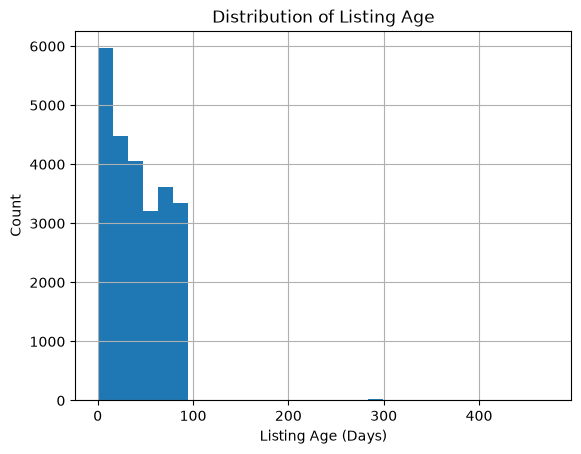

In [37]:
df["listing_age_days"].hist(bins=30)
plt.xlabel("Listing Age (Days)")
plt.ylabel("Count")
plt.title("Distribution of Listing Age")
plt.show()

In [38]:
df = df[(df["year"] >= 1970) & (df["year"] <= 2026)]
df["year"] = df["year"].astype(int)
df = df[df["price"] != "-"]

In [39]:
df["price"].dtype

dtype('float64')

In [40]:
df["price"].head(10)

0     1640000.0
1     3650000.0
2      800000.0
3      360000.0
5      480000.0
6      660000.0
7      580000.0
8     2650000.0
9     1300000.0
10     390000.0
Name: price, dtype: float64

In [41]:
df["price"].apply(type).value_counts()

price
<class 'float'>    24322
Name: count, dtype: int64

In [42]:
print(df.shape)

(24322, 14)


In [43]:
df["price"].isna().sum()

np.int64(107)

In [44]:
df[df["price"].isna()][["title", "price"]].head(10)

,title,price
14,Nissan Sentra 2024,NaN
20,Suzuki Ciaz 2021,NaN
55,MG ZS 2021,NaN
347,Hyundai Tucson GDI 2019,NaN
1300,Baic X3 2022,NaN
1305,Fiat Tipo 2024,NaN
1468,Volkswagen Jetta 2014,NaN
1970,Toyota Corolla 1996,NaN
2016,Toyota Yaris 2008,NaN
2030,Dodge Caravan 1998,NaN


In [45]:
df = df.dropna(subset=["price"])
df["price"] = df["price"].astype(int)

In [46]:
print(df.shape)

(24215, 14)


In [47]:
df = df.dropna(subset=["price"]).copy()
df = df[df["price"].notna()].copy()
df["price"] = df["price"].astype(int)

In [48]:
print(df["price"].isna().sum())

0


In [49]:
df[df["price"].isna()][["title", "price"]].head(20)

,title,price


In [50]:
import numpy as np

print(np.isinf(df["price"]).sum())

0


In [51]:
print(df["price"].dtype)

int64


In [52]:
print(df.shape)
print()
print(df.info())
print()
print(df.isna().sum())

(24215, 14)

<class 'pandas.core.frame.DataFrame'>
Index: 24215 entries, 0 to 24687
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             24215 non-null  object        
 1   company           24215 non-null  object        
 2   model             24215 non-null  object        
 3   year              24215 non-null  int64         
 4   price             24215 non-null  int64         
 5   mileage           22870 non-null  object        
 6   color             24215 non-null  object        
 7   transmission      305 non-null    object        
 8   location          24215 non-null  object        
 9   date_posted       24215 non-null  datetime64[ns]
 10  features          16558 non-null  object        
 11  detail_link       24215 non-null  object        
 12  transmission_raw  305 non-null    string        
 13  listing_age_days  24215 non-null  int64         
dtypes: datetime64[

In [53]:
print(df["year"].describe())
print(df["year"].value_counts().sort_index().tail(20))
print(df["year"].value_counts().sort_index().head(20))

count    24215.000000
mean      2013.110964
std          8.827151
min       1972.000000
25%       2008.000000
50%       2015.000000
75%       2020.000000
max       2026.000000
Name: year, dtype: float64
year
2007     757
2008    1036
2009     752
2010    1018
2011     816
2012     745
2013     982
2014     915
2015    1340
2016    1260
2017    1129
2018     927
2019    1290
2020    1361
2021    1688
2022    1606
2023     749
2024     781
2025     557
2026      43
Name: count, dtype: int64
year
1972     2
1973     1
1974     2
1975    34
1976    11
1977    24
1978    16
1979    38
1980    36
1981    24
1982    47
1983    36
1984    40
1985    38
1986    32
1987    28
1988    31
1989    31
1990    50
1991    49
Name: count, dtype: int64


In [54]:
# Clean mileage before any numerical inspection or outlier analysis
# -----------------------------------------------------------------
# Examples: '189,000 Km' -> 189000, missing values remain NaN.
df["mileage"] = (
    df["mileage"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.replace(" Km", "", regex=False)
    .str.strip()
)

df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")

print("Mileage dtype:", df["mileage"].dtype)
print("Missing mileage values:", df["mileage"].isna().sum())
df["mileage"].head()


Mileage dtype: Int64
Missing mileage values: 1345


0     58000
1     80000
2    100000
3    270000
5    250000
Name: mileage, dtype: Int64

In [55]:
print(df["mileage"].dtype)

Int64


In [56]:
print(df["mileage"].head(10))

0      58000
1      80000
2     100000
3     270000
5     250000
6     110000
7     120000
8       4800
9     139000
10    143000
Name: mileage, dtype: Int64


In [57]:
print(df["mileage"].apply(type).value_counts())

mileage
<class 'float'>    24215
Name: count, dtype: int64


In [58]:
df["mileage"].describe()

count          22870.0
mean     158192.016222
std      149673.176405
min                0.0
25%            87000.0
50%           149000.0
75%           207000.0
max         10000000.0
Name: mileage, dtype: Float64

In [59]:
df["mileage"].isna().sum()

np.int64(1345)

In [60]:
# Inspect the largest mileage values
assert pd.api.types.is_numeric_dtype(df["mileage"]), (
    "Mileage must be numeric. Run the mileage-cleaning cell above first."
)
df.nlargest(20, "mileage")[["title", "year", "mileage", "price"]]


,title,year,mileage,price
3249,Renault 9 1990,1990,10000000,70000
8473,Mitsubishi Lancer 1989,1989,10000000,135000
8903,Renault Logan 2013,2013,3700000,260000
7008,Mercedes 180 2006,2006,3500000,700000
11252,Suzuki Alto 2008,2008,3000000,190000
8425,Mitsubishi Lancer EX Shark 2016,2016,2980000,550000
21008,Mercedes 200 1984,1984,2580000,267000
2502,Fiat 128 1986,1986,2323333,56000
3945,Speranza A516 2008,2008,2300000,220000
16172,Kia Spectra 2003,2003,2180000,300000


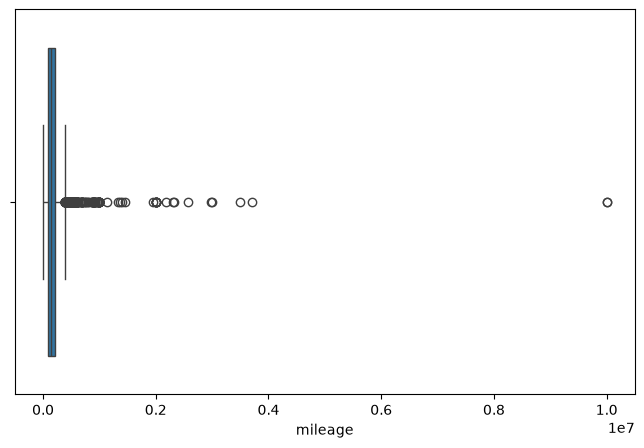

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df["mileage"])
plt.show()

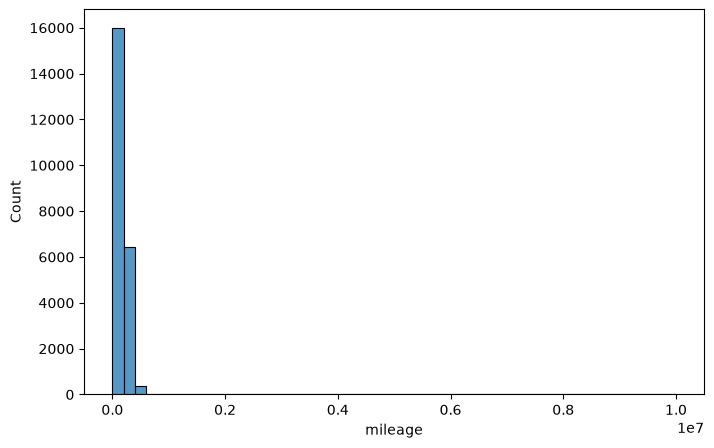

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(df["mileage"], bins=50)
plt.show()

In [63]:
df = df[df["mileage"] <= 1_000_000]
df.shape

(22847, 14)

In [64]:
df["price"].describe()

count    2.284700e+04
mean     9.946039e+05
std      1.160533e+07
min      1.111000e+03
25%      3.750000e+05
50%      6.100000e+05
75%      9.250000e+05
max      1.000000e+09
Name: price, dtype: float64

In [65]:
df.nlargest(20, "price")[["title", "price"]]

,title,price
5227,Toyota Fortuner 2024,1000000000
8382,Acura Other 2024,1000000000
8848,Tesla Model 3 2018,1000000000
8955,Nissan Qashqai 2018,125000000
19680,Opel Insignia 2017,125000000
18951,Toyota Corolla 2002,111111111
8846,Acura Other 2026,100000000
17924,MG ZS 2020,99999999
6382,Mercedes G 63 AMG 2025,19300000
2646,Cadillac Escalade 2025,18000000


In [66]:
df = df[df["price"] < 50_000_000]
df["price"].describe()

count    2.283900e+04
mean     8.390299e+05
std      9.336939e+05
min      1.111000e+03
25%      3.750000e+05
50%      6.100000e+05
75%      9.250000e+05
max      1.930000e+07
Name: price, dtype: float64

In [67]:
df.nlargest(20, "price")[["title", "price"]]

,title,price
6382,Mercedes G 63 AMG 2025,19300000
2646,Cadillac Escalade 2025,18000000
19051,Jeep Grand Cherokee 2015,16500000
10388,Land Rover Range Rover Vogue 2025,15500000
11436,Mercedes G Class 2023,15500000
18510,Mercedes G63 2022,14200000
18578,Hyundai Tucson 2019,14000000
23915,Mercedes G Class 2022,14000000
22244,Mercedes G Class 2022,13900000
19853,Mercedes S 500 2023,13500000


In [68]:
df.nsmallest(20, "price")[["title", "year", "price"]]

,title,year,price
4506,Skoda Fantasia 2010,2010,1111
17851,Kia K3 2022,2022,1250
692,MG Rx5 2023,2023,1300
18513,Skoda Kodiaq 2020,2020,1750
4364,Volkswagen Polo 1998,1998,2000
18351,Volkswagen Tiguan 2025,2025,2200
7072,Skoda Rapid Spaceback 2015,2015,3000
20627,Speranza A516 2008,2008,6000
3910,Hyundai Elantra AD 2019,2019,9000
6370,Hyundai Elantra CN7 2022,2022,9999


In [69]:
fake_prices = [
    11111111,
    111111111,
    12345664
]

df = df[~df["price"].isin(fake_prices)]

In [70]:
df[df["price"] < 100000]["price"].value_counts().sort_index()

price
1111      1
1250      1
1300      1
1750      1
2000      1
2200      1
3000      1
6000      1
9000      1
9999      1
11111     3
12000     1
13500     1
22000     1
27000     1
30000     1
31000     1
35000     6
38000     3
38500     1
40000     9
41000     3
42000     1
43000     1
45000     6
47000     2
48000     3
50000    11
50500     1
51999     1
52000     3
55000    11
56000     1
57000     2
58000     1
59000     1
60000    17
62000     1
65000    18
66000     1
67000     3
68000     1
70000    13
75000     9
77000     1
78000     1
79000     1
80000    16
85000    20
88000     1
90000    29
92000     1
95000    19
98000     1
99000     1
Name: count, dtype: int64

In [71]:
df = df[df["price"] >= 12000]

In [72]:
mask = (df["year"] >= 2015) & (df["price"] < 100000)

df = df[~mask]

In [73]:
mask = (df["year"] >= 2015) & (df["price"] < 100000)

df.loc[mask, ["title", "year", "price"]].sort_values("price")

,title,year,price


In [74]:
df.nsmallest(30, "price")[["title", "year", "price"]]

,title,year,price
18964,Skoda Felicia 1997,1997,12000
10574,Skoda Felicia 1995,1995,13500
1951,Kia Rio 2004,2004,27000
134,Seat 133 1980,1980,30000
350,Fiat 127 1985,1985,35000
1177,Fiat 127 1982,1982,35000
2193,Fiat 128 1982,1982,35000
3292,Seat 133 1981,1981,35000
18649,Fiat 128 1975,1975,35000
4187,Fiat 127 1987,1987,38000


In [75]:
df.nlargest(30, "price")[["title", "year", "price"]]

,title,year,price
6382,Mercedes G 63 AMG 2025,2025,19300000
2646,Cadillac Escalade 2025,2025,18000000
19051,Jeep Grand Cherokee 2015,2015,16500000
10388,Land Rover Range Rover Vogue 2025,2025,15500000
11436,Mercedes G Class 2023,2023,15500000
18510,Mercedes G63 2022,2022,14200000
18578,Hyundai Tucson 2019,2019,14000000
23915,Mercedes G Class 2022,2022,14000000
22244,Mercedes G Class 2022,2022,13900000
19853,Mercedes S 500 2023,2023,13500000


In [76]:
bad_titles = [
    "Hyundai Tucson 2019",
    "BMW 325 2008",
    "BMW 320 2013",
    "Renault Megane 2021",
    "Hyundai Accent 2010"
]

df = df[~df["title"].isin(bad_titles)]

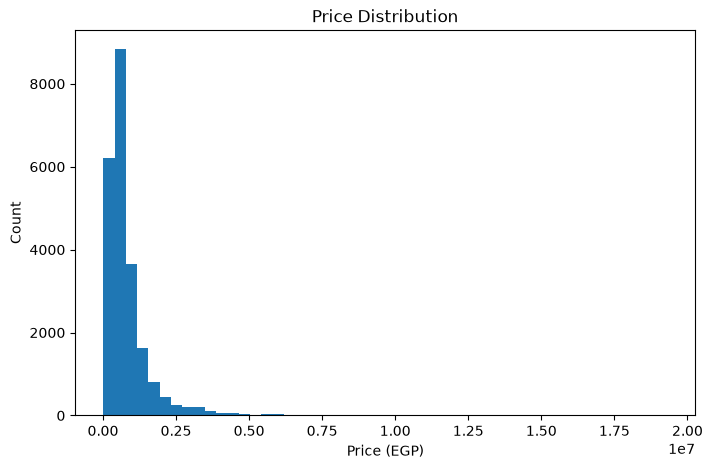

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.xlabel("Price (EGP)")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

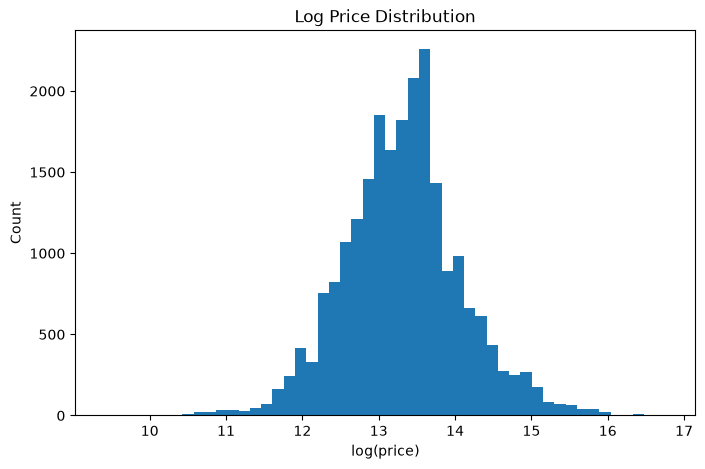

In [78]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["price"]), bins=50)
plt.xlabel("log(price)")
plt.ylabel("Count")
plt.title("Log Price Distribution")
plt.show()

In [79]:
df["mileage"].describe()

count          22713.0
mean     155639.825871
std        99421.33986
min                0.0
25%            87000.0
50%           149000.0
75%           207000.0
max          1000000.0
Name: mileage, dtype: Float64

In [80]:
df[df["mileage"] >= 1_000_000][["title", "year", "mileage"]]

,title,year,mileage
9313,Fiat Regata 1985,1985,1000000
21961,Hyundai Elantra 1997,1997,1000000
21998,Kia Spectra 2001,2001,1000000
22127,Fiat 128 1975,1975,1000000
24271,Fiat Florida 2005,2005,1000000


In [81]:
df = df[df["mileage"] < 1_000_000]

In [82]:
# Rebuild transmission without erasing the original Manual/Automatic values
# -------------------------------------------------------------------------
# Priority 1: keep the value supplied by the raw dataset.
# Priority 2: for missing rows, use the features text.
#             - 'Automatic' in features  -> Automatic
#             - non-empty features without 'Automatic' -> Manual
#             - missing features -> keep as NaN (unknown)

# Restore the preserved raw values for the rows that survived cleaning.
df["transmission"] = df["transmission_raw"].astype("string")

# Normalize explicit raw labels.
df["transmission"] = (
    df["transmission"]
    .str.strip()
    .str.title()
    .replace({"Nan": pd.NA, "None": pd.NA, "": pd.NA})
)

features_text = df["features"].astype("string").str.strip()
has_features = features_text.notna() & features_text.ne("")
mentions_automatic = features_text.str.contains(
    r"\bAutomatic\b", case=False, na=False, regex=True
)

# Fill only rows whose original transmission is missing.
missing_transmission = df["transmission"].isna()
df.loc[missing_transmission & mentions_automatic, "transmission"] = "Automatic"
df.loc[
    missing_transmission & has_features & ~mentions_automatic,
    "transmission"
] = "Manual"

# Keep rows with missing feature text as unknown rather than fabricating a label.
df["transmission"] = df["transmission"].astype("category")

print(df["transmission"].value_counts(dropna=False))
print("\nRows still unknown:", df["transmission"].isna().sum())


transmission
Automatic    13552
<NA>          6885
Manual        2271
Name: count, dtype: int64

Rows still unknown: 6885


In [83]:
df["air_conditioner"] = df["features"].str.contains("Air Conditioner", na=False)
df["power_steering"] = df["features"].str.contains("Power Steering", na=False)
df["remote_control"] = df["features"].str.contains("Remote Control", na=False)
df["power_windows"] = df["features"].str.contains("Power Windows", na=False)
df["airbags"] = df["features"].str.contains("Airbags", na=False)

In [84]:
df["transmission"].value_counts()

transmission
Automatic    13552
Manual        2271
Name: count, dtype: int64

In [85]:
np.where(
    df["features"].str.contains("Automatic", case=False, na=False),
    "Automatic",
    "Manual"
)

array(['Manual', 'Automatic', 'Automatic', ..., 'Automatic', 'Automatic',
       'Manual'], shape=(22708,), dtype='<U9')

In [86]:
df[df["features"].isna()].shape

(6892, 19)

In [87]:
print(df["features"].isna().sum())
print(df["features"].notna().sum())

6892
15816


In [88]:
print(df["transmission"].dtype)

category


In [89]:

print(df["transmission"].head())

0         <NA>
1    Automatic
2    Automatic
3    Automatic
5    Automatic
Name: transmission, dtype: category
Categories (2, string): [Automatic, Manual]


In [90]:
df["features"].str.contains("Manual", case=False, na=False).sum()

np.int64(0)

In [91]:
# Transmission extraction is handled in the earlier corrected cell.


In [92]:
# Transmission extraction is handled in the earlier corrected cell.


In [93]:
df["transmission"].value_counts(dropna=False)

transmission
Automatic    13552
<NA>          6885
Manual        2271
Name: count, dtype: int64

In [94]:
print(df["transmission"].dtype)

print(df["transmission"].value_counts(dropna=False))

print(df["transmission"].unique()[:10])

category
transmission
Automatic    13552
<NA>          6885
Manual        2271
Name: count, dtype: int64
[<NA>, 'Automatic', 'Manual']
Categories (2, string): [Automatic, Manual]


In [95]:
df.duplicated().sum()

np.int64(112)

In [96]:
# Final transmission validation
transmission_check = pd.DataFrame({
    "count": df["transmission"].value_counts(dropna=False),
    "percentage": (
        df["transmission"].value_counts(dropna=False, normalize=True) * 100
    ).round(2),
})
transmission_check


,count,percentage
transmission,,
Automatic,13552,59.68
<NA>,6885,30.32
Manual,2271,10.00


In [97]:
df.isna().sum().sort_values(ascending=False)

transmission_raw    22406
features             6892
transmission         6885
model                   0
company                 0
title                   0
year                    0
color                   0
mileage                 0
location                0
price                   0
date_posted             0
detail_link             0
listing_age_days        0
air_conditioner         0
power_steering          0
remote_control          0
power_windows           0
airbags                 0
dtype: int64

In [98]:
import pandas as pd
import numpy as np

raw_path = r"C:\Users\Asus\OneDrive\Desktop\ML_WORK\Used_Car_Price_Prediction\data\used_cars\hatla2ee_cars_august_2025.csv"

raw_df = pd.read_csv(raw_path)

print(raw_df.shape)
print(raw_df.columns.tolist())

(24688, 12)
['title', 'company', 'model', 'year', 'price', 'mileage', 'color', 'transmission', 'location', 'date_posted', 'features', 'detail_link']


In [99]:
df["features"] = raw_df.loc[df.index, "features"]
print("features" in df.columns)
print(df["features"].isna().sum())

True
6892


In [100]:
# Restore original transmission values from the raw CSV
df["transmission"] = (
    raw_df.loc[df.index, "transmission"]
    .astype("string")
    .str.strip()
    .str.title()
)

df["transmission"] = df["transmission"].replace({
    "": pd.NA,
    "Nan": pd.NA,
    "None": pd.NA
})

features_text = df["features"].astype("string").str.strip()

has_features = features_text.notna() & features_text.ne("")

mentions_automatic = features_text.str.contains(
    r"\bAutomatic\b",
    case=False,
    na=False,
    regex=True
)

mentions_manual = features_text.str.contains(
    r"\bManual\b",
    case=False,
    na=False,
    regex=True
)

# Fill missing transmission only
missing_transmission = df["transmission"].isna()

df.loc[
    missing_transmission & mentions_automatic,
    "transmission"
] = "Automatic"

df.loc[
    missing_transmission & mentions_manual,
    "transmission"
] = "Manual"

# Infer Manual only when a features list exists but Automatic is absent
still_missing = df["transmission"].isna()

df.loc[
    still_missing & has_features & ~mentions_automatic,
    "transmission"
] = "Manual"

print(df["transmission"].value_counts(dropna=False))

transmission
Automatic    13552
<NA>          6885
Manual        2271
Name: count, dtype: Int64


In [101]:
feature_map = {
    "air_conditioner": "Air Conditioner",
    "power_steering": "Power Steering",
    "remote_control": "Remote Control",
    "power_windows": "Power Windows",
    "airbags": "Air Bags",
    "abs": "ABS",
    "electric_mirrors": "Electric Mirrors",
    "sunroof": "Sunroof",
    "leather_seats": "Leather Seats",
    "cruise_control": "Cruise Control",
    "central_lock": "Central Lock",
    "bluetooth": "Bluetooth",
    "navigation": "Navigation",
    "parking_sensors": "Parking Sensors"
}

for column_name, feature_name in feature_map.items():
    df[column_name] = (
        df["features"]
        .str.contains(
            feature_name,
            case=False,
            na=False,
            regex=False
        )
        .astype("int8")
    )

In [102]:
df["transmission"].value_counts(dropna=False)

transmission
Automatic    13552
<NA>          6885
Manual        2271
Name: count, dtype: Int64

In [103]:
feature_columns = list(feature_map.keys())

print(df[feature_columns].sum().sort_values(ascending=False))
df[feature_columns].head()

air_conditioner     12951
remote_control      12033
power_steering      10685
power_windows           0
airbags                 0
abs                     0
electric_mirrors        0
sunroof                 0
leather_seats           0
cruise_control          0
central_lock            0
bluetooth               0
navigation              0
parking_sensors         0
dtype: int64


,air_conditioner,power_steering,remote_control,power_windows,airbags,abs,electric_mirrors,sunroof,leather_seats,cruise_control,central_lock,bluetooth,navigation,parking_sensors
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,0,0,0,0,0
3,1,0,1,0,0,0,0,0,0,0,0,0,0,0
5,1,1,1,0,0,0,0,0,0,0,0,0,0,0


In [104]:
df.drop(
    columns=["features", "transmission_raw"],
    inplace=True,
    errors="ignore"
)

In [105]:
print(df.shape)
print(df["transmission"].value_counts(dropna=False))
print(df.isna().sum().sort_values(ascending=False).head(10))

(22708, 26)
transmission
Automatic    13552
<NA>          6885
Manual        2271
Name: count, dtype: Int64
transmission    6885
title              0
company            0
model              0
price              0
year               0
mileage            0
color              0
location           0
date_posted        0
dtype: int64


In [106]:
df["color"].value_counts()

color
Silver        4684
Black         4330
White         2617
Red           2141
Blue          1248
Gray          1188
Dark grey     1078
Dark blue      941
Dark red       778
Gold           537
Bronze         477
Petroleum      477
Other          383
Cyan           367
Green          333
Mocha          273
Brown          268
Dark green     164
Eggplant       106
Beige           83
Champagne       82
Orange          65
Olive           56
Purple          21
Yellow          11
Name: count, dtype: int64

In [107]:
print(df.duplicated().sum())

112


In [108]:
df = df.drop_duplicates()

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22596 entries, 0 to 24599
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             22596 non-null  object        
 1   company           22596 non-null  object        
 2   model             22596 non-null  object        
 3   year              22596 non-null  int64         
 4   price             22596 non-null  int64         
 5   mileage           22596 non-null  Int64         
 6   color             22596 non-null  object        
 7   transmission      15745 non-null  string        
 8   location          22596 non-null  object        
 9   date_posted       22596 non-null  datetime64[ns]
 10  detail_link       22596 non-null  object        
 11  listing_age_days  22596 non-null  int64         
 12  air_conditioner   22596 non-null  int8          
 13  power_steering    22596 non-null  int8          
 14  remote_control    22596 non

In [110]:
raw_path = r"C:\Users\Asus\OneDrive\Desktop\ML_WORK\Used_Car_Price_Prediction\data\used_cars\hatla2ee_cars_august_2025.csv"

raw_df = pd.read_csv(raw_path)

df["features"] = raw_df.loc[df.index, "features"]

In [111]:
all_features = (
    df["features"]
    .dropna()
    .str.split("|", regex=False)
    .explode()
    .str.strip()
)

feature_counts = all_features.value_counts()

print("Number of unique features:", feature_counts.shape[0])
print(feature_counts.to_string())

Number of unique features: 4
features
Automatic          13473
Air Conditioner    12886
Remote Control     11977
Power Steering     10631


In [112]:
from sklearn.preprocessing import MultiLabelBinarizer

feature_lists = (
    df["features"]
    .fillna("")
    .apply(
        lambda value: [
            item.strip()
            for item in value.split("|")
            if item.strip()
        ]
    )
)

mlb = MultiLabelBinarizer()

encoded_features = pd.DataFrame(
    mlb.fit_transform(feature_lists),
    columns=mlb.classes_,
    index=df.index
)

encoded_features.head()

,Air Conditioner,Automatic,Power Steering,Remote Control
0,0,0,0,0
1,1,1,0,0
2,1,1,1,1
3,1,1,0,1
5,1,1,1,1


In [113]:
print(encoded_features.columns.tolist())

['Air Conditioner', 'Automatic', 'Power Steering', 'Remote Control']


In [114]:
encoded_features.columns = (
    encoded_features.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

In [115]:
existing_engineered = [
    "air_conditioner",
    "power_steering",
    "remote_control",
    "power_windows",
    "airbags",
    "abs",
    "electric_mirrors",
    "sunroof",
    "leather_seats",
    "cruise_control",
    "central_lock",
    "bluetooth",
    "navigation",
    "parking_sensors",
]

df.drop(
    columns=existing_engineered,
    inplace=True,
    errors="ignore"
)

In [116]:
df = pd.concat([df, encoded_features], axis=1)
df.drop(columns="features", inplace=True, errors="ignore")

In [117]:
print("Shape:", df.shape)

print("\nTransmission:")
print(df["transmission"].value_counts(dropna=False))

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nData types:")
df.info()

Shape: (22596, 16)

Transmission:
transmission
Automatic    13476
<NA>          6851
Manual        2269
Name: count, dtype: Int64

Missing values:
transmission    6851
title              0
model              0
company            0
year               0
price              0
mileage            0
color              0
location           0
date_posted        0
dtype: int64

Data types:
<class 'pandas.core.frame.DataFrame'>
Index: 22596 entries, 0 to 24599
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             22596 non-null  object        
 1   company           22596 non-null  object        
 2   model             22596 non-null  object        
 3   year              22596 non-null  int64         
 4   price             22596 non-null  int64         
 5   mileage           22596 non-null  Int64         
 6   color             22596 non-null  object        
 7   transmission      1574

In [118]:
df["company"].value_counts()

company
Hyundai      2427
Kia          1870
Renault      1617
Chevrolet    1597
Nissan       1220
             ... 
Datsun          1
Abarth          1
Buick           1
Pontiac         1
Hummer          1
Name: count, Length: 103, dtype: int64

In [119]:
df["model"].value_counts()

model
Lancer       687
Sunny        683
Elantra      640
Lanos        607
Corolla      576
            ... 
Murano         1
Silverado      1
DX7            1
Englon         1
460            1
Name: count, Length: 663, dtype: int64

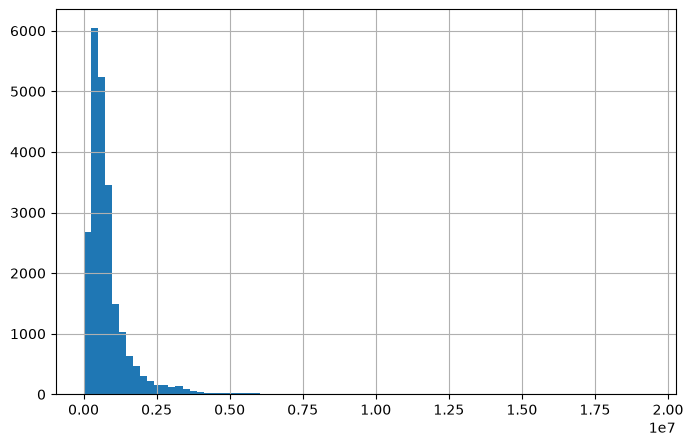

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["price"].hist(bins=80)
plt.show()

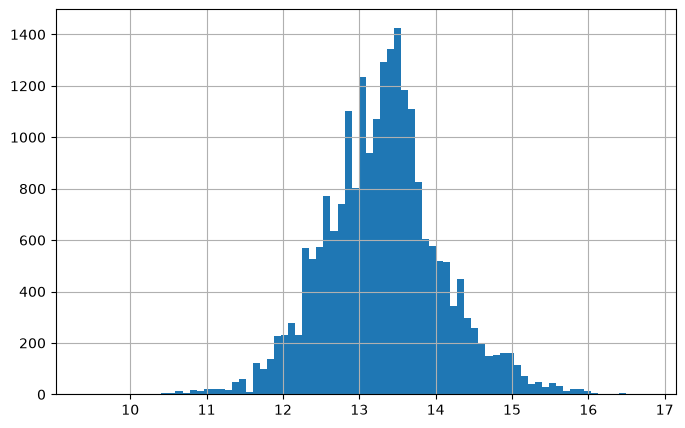

In [121]:
import numpy as np

plt.figure(figsize=(8,5))
np.log1p(df["price"]).hist(bins=80)
plt.show()

In [122]:
CURRENT_YEAR = 2026

df["car_age"] = CURRENT_YEAR - df["year"]

df[["year", "car_age"]].head()

,year,car_age
0,2018,8
1,2019,7
2,2021,5
3,2005,21
5,2003,23


In [123]:
X = df.drop(
    columns=[
        "price",
        "title",
        "detail_link",
        "date_posted",
        "year"
    ],
    errors="ignore"
).copy()

y = np.log1p(df["price"]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (22596, 12)
y shape: (22596,)


In [124]:
X = X.loc[:, ~X.columns.duplicated()].copy()

print(X.columns.tolist())

['company', 'model', 'mileage', 'color', 'transmission', 'location', 'listing_age_days', 'air_conditioner', 'automatic', 'power_steering', 'remote_control', 'car_age']


In [125]:
X.drop(columns=["ain_conditioner"], inplace=True, errors="ignore")

In [126]:
X["transmission"] = X["transmission"].fillna("Unknown")
X["transmission"].value_counts(dropna=False)

transmission
Automatic    13476
Unknown       6851
Manual        2269
Name: count, dtype: Int64

In [127]:
X["mileage"] = X["mileage"].astype("int64")

In [128]:
print(X.dtypes)
print("\nShape:", X.shape)
print("\nMissing values:")
print(X.isna().sum().sort_values(ascending=False).head())

company                     object
model                       object
mileage                      int64
color                       object
transmission        string[python]
location                    object
listing_age_days             int64
air_conditioner              int64
automatic                    int64
power_steering               int64
remote_control               int64
car_age                      int64
dtype: object

Shape: (22596, 12)

Missing values:
company         0
model           0
mileage         0
color           0
transmission    0
dtype: int64


In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (18076, 12)
Testing features: (4520, 12)


In [130]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [
    "company",
    "model",
    "color",
    "transmission",
    "location"
]

numeric_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_cols
        ),
        (
            "num",
            "passthrough",
            numeric_cols
        )
    ]
)

In [131]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(18076, 12)
(4520, 12)


In [132]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_encoded, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [133]:
y_pred_lr = lr.predict(X_test_encoded)

In [134]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Convert back to original prices
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_lr)

mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

MAE : 344,500.53
RMSE: 825,815.38
R²  : 0.2357


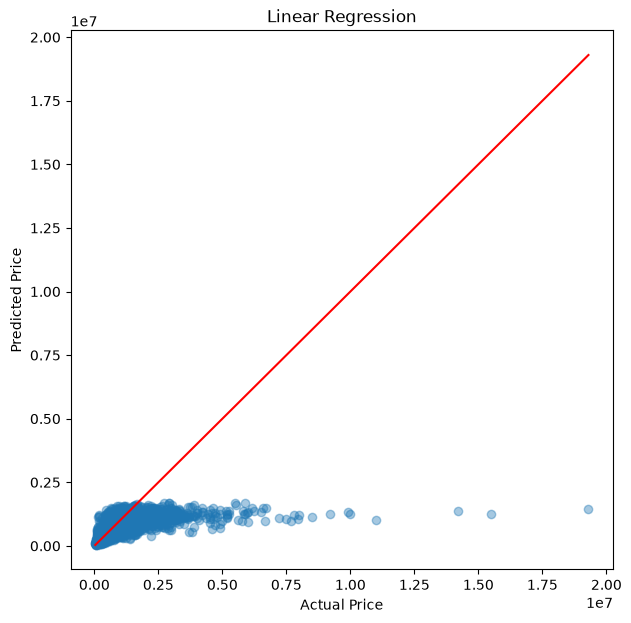

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test_original,
    y_pred_original,
    alpha=0.4
)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression")

plt.show()

In [136]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train_encoded, y_train)

y_pred_dt = dt.predict(X_test_encoded)

In [137]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_dt_price = np.expm1(y_pred_dt)

mae = mean_absolute_error(y_test_original, y_pred_dt_price)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_dt_price))
r2 = r2_score(y_test_original, y_pred_dt_price)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

MAE : 175,015.00
RMSE: 569,046.33
R²  : 0.6371


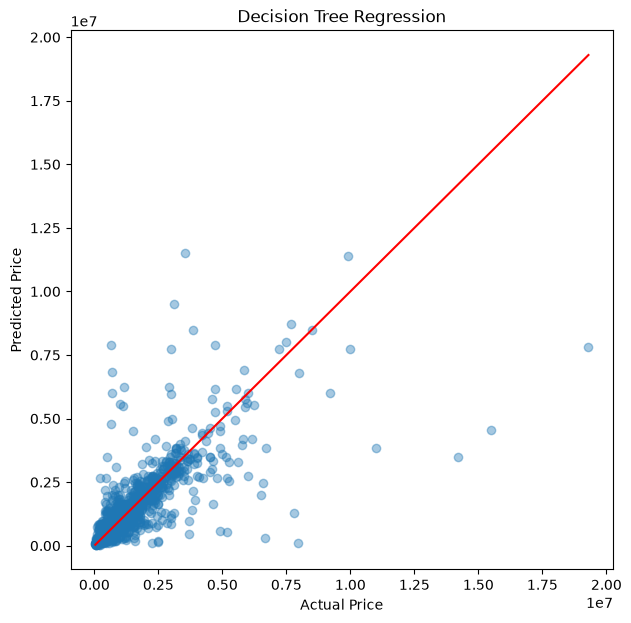

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test_original,
    y_pred_dt_price,
    alpha=0.4
)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree Regression")

plt.show()

In [139]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_encoded, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [140]:
y_pred_rf = rf.predict(X_test_encoded)

In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_rf_price = np.expm1(y_pred_rf)

mae = mean_absolute_error(y_test_original, y_pred_rf_price)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_rf_price))
r2 = r2_score(y_test_original, y_pred_rf_price)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

MAE : 130,675.89
RMSE: 467,832.52
R²  : 0.7547


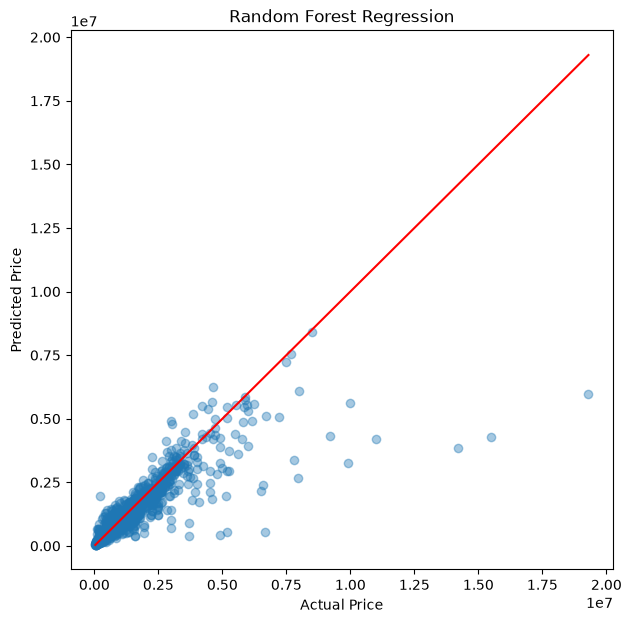

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test_original,
    y_pred_rf_price,
    alpha=0.4
)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Regression")

plt.show()

In [143]:
results = []

results.append({
    "Model": "Linear Regression",
    "MAE": 344500.53,
    "RMSE": 825815.38,
    "R2": 0.2357
})

results.append({
    "Model": "Decision Tree",
    "MAE": 175015.00,
    "RMSE": 569046.33,
    "R2": 0.6371
})

In [144]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_encoded, y_train)

y_pred_xgb_log = xgb.predict(X_test_encoded)

# Convert log predictions back to EGP
y_pred_xgb_price = np.expm1(y_pred_xgb_log)
y_test_price = np.expm1(y_test)

mae_xgb = mean_absolute_error(y_test_price, y_pred_xgb_price)
rmse_xgb = np.sqrt(
    mean_squared_error(y_test_price, y_pred_xgb_price)
)
r2_xgb = r2_score(y_test_price, y_pred_xgb_price)

print(f"MAE : {mae_xgb:,.2f}")
print(f"RMSE: {rmse_xgb:,.2f}")
print(f"R²  : {r2_xgb:.4f}")

MAE : 119,622.59
RMSE: 399,400.78
R²  : 0.8212


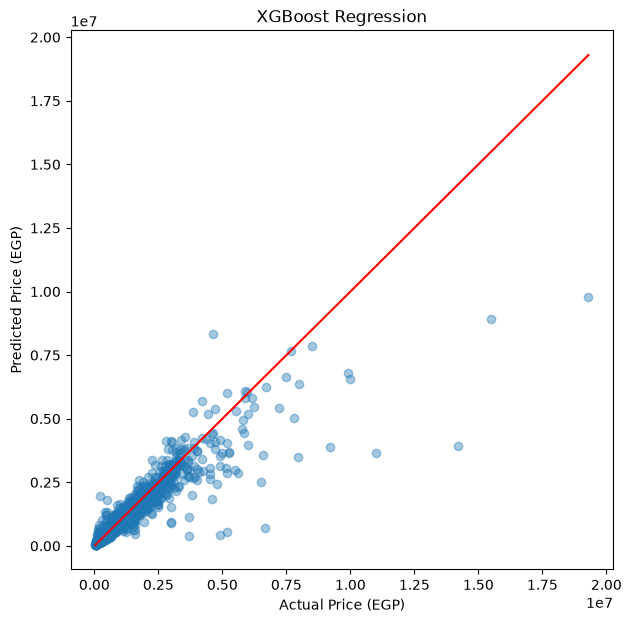

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_price,
    y_pred_xgb_price,
    alpha=0.4
)

minimum = min(y_test_price.min(), y_pred_xgb_price.min())
maximum = max(y_test_price.max(), y_pred_xgb_price.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red"
)

plt.xlabel("Actual Price (EGP)")
plt.ylabel("Predicted Price (EGP)")
plt.title("XGBoost Regression")

plt.show()

In [146]:
from xgboost import XGBRegressor

xgb_tuned = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1.5,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(
    X_train_encoded,
    y_train,
    eval_set=[(X_test_encoded, y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.75426
[100]	validation_0-rmse:0.35941
[200]	validation_0-rmse:0.29197
[300]	validation_0-rmse:0.26168
[400]	validation_0-rmse:0.24578
[500]	validation_0-rmse:0.23645
[600]	validation_0-rmse:0.22995
[700]	validation_0-rmse:0.22434
[800]	validation_0-rmse:0.22070
[900]	validation_0-rmse:0.21784
[1000]	validation_0-rmse:0.21510
[1100]	validation_0-rmse:0.21304
[1200]	validation_0-rmse:0.21125
[1300]	validation_0-rmse:0.20973
[1400]	validation_0-rmse:0.20854
[1500]	validation_0-rmse:0.20727
[1600]	validation_0-rmse:0.20642
[1700]	validation_0-rmse:0.20557
[1800]	validation_0-rmse:0.20478
[1900]	validation_0-rmse:0.20408
[1999]	validation_0-rmse:0.20356


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [147]:
y_pred_tuned_log = xgb_tuned.predict(X_test_encoded)

y_pred_tuned_price = np.expm1(y_pred_tuned_log)
y_test_price = np.expm1(y_test)

mae_tuned = mean_absolute_error(
    y_test_price,
    y_pred_tuned_price
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test_price,
        y_pred_tuned_price
    )
)

r2_tuned = r2_score(
    y_test_price,
    y_pred_tuned_price
)

print(f"MAE : {mae_tuned:,.2f}")
print(f"RMSE: {rmse_tuned:,.2f}")
print(f"R²  : {r2_tuned:.4f}")

MAE : 118,086.95
RMSE: 385,611.96
R²  : 0.8334


In [148]:
xgb_tuned.fit(
    X_train_encoded,
    y_train,
    eval_set=[(X_test_encoded, y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.75426


[100]	validation_0-rmse:0.35941
[200]	validation_0-rmse:0.29197
[300]	validation_0-rmse:0.26168
[400]	validation_0-rmse:0.24578
[500]	validation_0-rmse:0.23645
[600]	validation_0-rmse:0.22995
[700]	validation_0-rmse:0.22434
[800]	validation_0-rmse:0.22070
[900]	validation_0-rmse:0.21784
[1000]	validation_0-rmse:0.21510
[1100]	validation_0-rmse:0.21304
[1200]	validation_0-rmse:0.21125
[1300]	validation_0-rmse:0.20973
[1400]	validation_0-rmse:0.20854
[1500]	validation_0-rmse:0.20727
[1600]	validation_0-rmse:0.20642
[1700]	validation_0-rmse:0.20557
[1800]	validation_0-rmse:0.20478
[1900]	validation_0-rmse:0.20408
[1999]	validation_0-rmse:0.20356


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [149]:
xgb_tuned.fit(
    X_train_encoded,
    y_train,
    eval_set=[(X_test_encoded, y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.75426


[100]	validation_0-rmse:0.35941
[200]	validation_0-rmse:0.29197
[300]	validation_0-rmse:0.26168
[400]	validation_0-rmse:0.24578
[500]	validation_0-rmse:0.23645
[600]	validation_0-rmse:0.22995
[700]	validation_0-rmse:0.22434
[800]	validation_0-rmse:0.22070
[900]	validation_0-rmse:0.21784
[1000]	validation_0-rmse:0.21510
[1100]	validation_0-rmse:0.21304
[1200]	validation_0-rmse:0.21125
[1300]	validation_0-rmse:0.20973
[1400]	validation_0-rmse:0.20854
[1500]	validation_0-rmse:0.20727
[1600]	validation_0-rmse:0.20642
[1700]	validation_0-rmse:0.20557
[1800]	validation_0-rmse:0.20478
[1900]	validation_0-rmse:0.20408
[1999]	validation_0-rmse:0.20356


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [150]:
y_pred_tuned_log = xgb_tuned.predict(X_test_encoded)

In [151]:
print(type(xgb))
print(type(xgb_tuned))

<class 'xgboost.sklearn.XGBRegressor'>
<class 'xgboost.sklearn.XGBRegressor'>


In [152]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:20])

12
['cat__company' 'cat__model' 'cat__color' 'cat__transmission'
 'cat__location' 'num__mileage' 'num__listing_age_days'
 'num__air_conditioner' 'num__automatic' 'num__power_steering'
 'num__remote_control' 'num__car_age']


                  Feature  Importance
8          num__automatic    0.349770
11           num__car_age    0.279961
0            cat__company    0.105531
3       cat__transmission    0.083182
5            num__mileage    0.051208
7    num__air_conditioner    0.042239
1              cat__model    0.041007
9     num__power_steering    0.015955
2              cat__color    0.012839
10    num__remote_control    0.006815
4           cat__location    0.006561
6   num__listing_age_days    0.004934


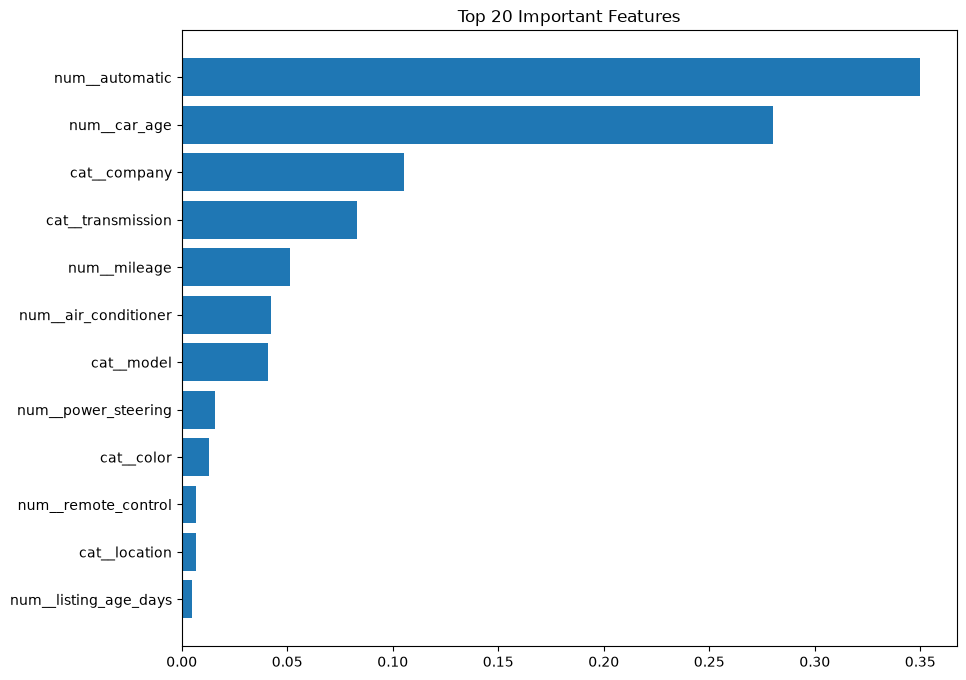

In [153]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_tuned.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

plt.figure(figsize=(10,8))
plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()

In [154]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Tell CatBoost which columns are categorical
categorical_features = [
    "company",
    "model",
    "color",
    "transmission",
    "location"
]

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

y_pred = cat_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

0:	learn: 0.7451207	total: 254ms	remaining: 4m 14s
100:	learn: 0.2609176	total: 7.14s	remaining: 1m 3s
200:	learn: 0.2361841	total: 14.2s	remaining: 56.5s
300:	learn: 0.2241061	total: 20.7s	remaining: 48s
400:	learn: 0.2148737	total: 26.9s	remaining: 40.2s
500:	learn: 0.2070408	total: 33s	remaining: 32.8s
600:	learn: 0.2009770	total: 38.9s	remaining: 25.8s
700:	learn: 0.1953045	total: 44.8s	remaining: 19.1s
800:	learn: 0.1900722	total: 51.2s	remaining: 12.7s
900:	learn: 0.1854996	total: 57.7s	remaining: 6.34s
999:	learn: 0.1807850	total: 1m 3s	remaining: 0us
MAE : 0.13
RMSE: 0.21
R²  : 0.9228


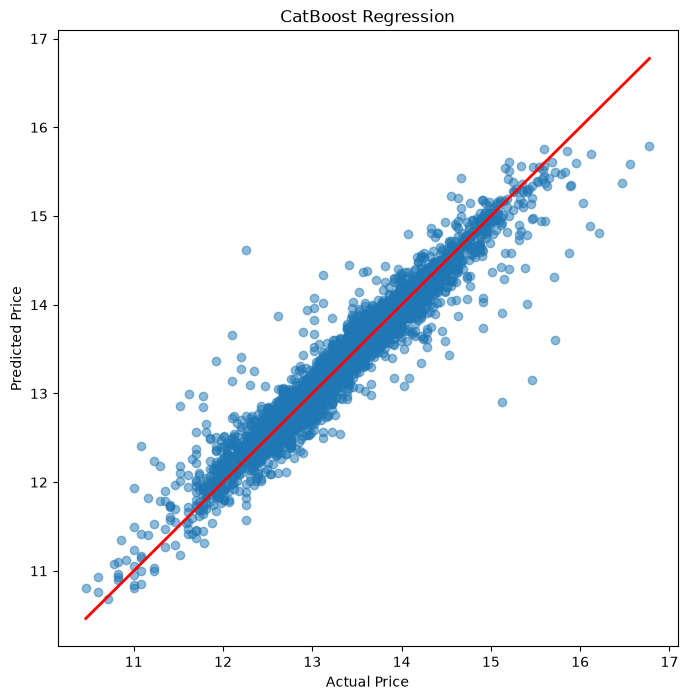

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("CatBoost Regression")

plt.show()

In [156]:
# Convert log predictions and targets back to EGP
y_pred_egp = np.expm1(y_pred)
y_test_egp = np.expm1(y_test)

mae_egp = mean_absolute_error(y_test_egp, y_pred_egp)
rmse_egp = np.sqrt(mean_squared_error(y_test_egp, y_pred_egp))
r2_egp = r2_score(y_test_egp, y_pred_egp)

print("CatBoost — Log scale")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

print("\nCatBoost — Original EGP scale")
print(f"MAE : {mae_egp:,.2f} EGP")
print(f"RMSE: {rmse_egp:,.2f} EGP")
print(f"R²  : {r2_egp:.4f}")

CatBoost — Log scale
MAE : 0.1342
RMSE: 0.2124
R²  : 0.9228

CatBoost — Original EGP scale
MAE : 129,672.11 EGP
RMSE: 452,268.86 EGP
R²  : 0.7708


In [157]:
# XGBoost prediction on the log scale
y_pred_log = xgb_tuned.predict(X_test_encoded)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("XGBoost (log scale)")
print("MAE :", mean_absolute_error(y_test, y_pred_log))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_log)))
print("R²  :", r2_score(y_test, y_pred_log))

XGBoost (log scale)
MAE : 0.12674527814403505
RMSE: 0.20356218323028705
R²  : 0.9291302683506346


In [158]:
print(y_train.head())

3097     13.955273
23737    12.644331
522      13.384729
23727    13.091906
5550     13.017005
Name: price, dtype: float64


In [159]:
print(cat_model)

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)


In [160]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

params = {
    "n_estimators": [500, 800, 1000, 1500],
    "max_depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2]
}

search = RandomizedSearchCV(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    params,
    n_iter=30,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train_encoded, y_train)

print(search.best_params_)
print(search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'subsample': 0.9, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
0.9163309206037245


In [161]:
from xgboost import XGBRegressor

best_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=1000,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=1.0,
    gamma=0,
    min_child_weight=1,
    n_jobs=-1
)

best_xgb.fit(X_train_encoded, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [162]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_log = best_xgb.predict(X_test_encoded)

print("LOG SCALE")
print("R²:", r2_score(y_test, y_pred_log))

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("\nEGP SCALE")
print("MAE :", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R²  :", r2_score(y_true, y_pred))

LOG SCALE
R²: 0.9266333761391217

EGP SCALE
MAE : 119246.03356782356
RMSE: 385680.53306611767
R²  : 0.8332987497108199


In [163]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_xgb)
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Fold R²:", scores)
print("Average:", scores.mean())

Fold R²: [0.91405248 0.91213833 0.92190441 0.91170385 0.91207464]
Average: 0.9143747411081542


In [164]:
print(y_train.describe())
print()
print(y_test.describe())

count    18076.000000
mean        13.315440
std          0.771487
min          9.392745
25%         12.821261
50%         13.321216
75%         13.737550
max         16.705882
Name: price, dtype: float64

count    4520.000000
mean       13.313743
std         0.764742
min        10.463132
25%        12.847929
50%        13.304687
75%        13.710151
max        16.775616
Name: price, dtype: float64


In [165]:
X_encoded = preprocessor.transform(X)

print(X_encoded.shape)

(22596, 12)


In [166]:
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_cv_pred = cross_val_predict(
    best_xgb,
    X_encoded,
    y,
    cv=cv,
    n_jobs=-1
)

print("Cross-validated R²:", r2_score(y, y_cv_pred))

Cross-validated R²: 0.9218292305254582


In [167]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_xgb)
])

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Fold R² scores:", cv_scores)
print("Average R²:", cv_scores.mean())
print("Std:", cv_scores.std())

Fold R² scores: [0.92758653 0.90918306 0.91812735 0.91546128 0.92193803]
Average R²: 0.9184592496340855
Std: 0.006173410128163025


In [168]:
X.head()

,company,model,mileage,color,transmission,location,listing_age_days,air_conditioner,automatic,power_steering,remote_control,car_age
0,Volkswagen,Tiguan,58000,Dark blue,Unknown,Alexandria,0,0,0,0,0,8
1,BMW,X6,80000,Silver,Automatic,Port Said,0,1,1,0,0,7
2,MG,ZS,100000,Silver,Automatic,Luxor,0,1,1,1,1,5
3,Chevrolet,Optra,270000,White,Automatic,6 October,0,1,1,0,1,21
5,Jeep,Liberty,250000,Dark red,Automatic,Alexandria,0,1,1,1,1,23


In [169]:
print(X.columns)

Index(['company', 'model', 'mileage', 'color', 'transmission', 'location',
       'listing_age_days', 'air_conditioner', 'automatic', 'power_steering',
       'remote_control', 'car_age'],
      dtype='object')


In [170]:
import joblib

joblib.dump(best_xgb, "best_xgboost.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

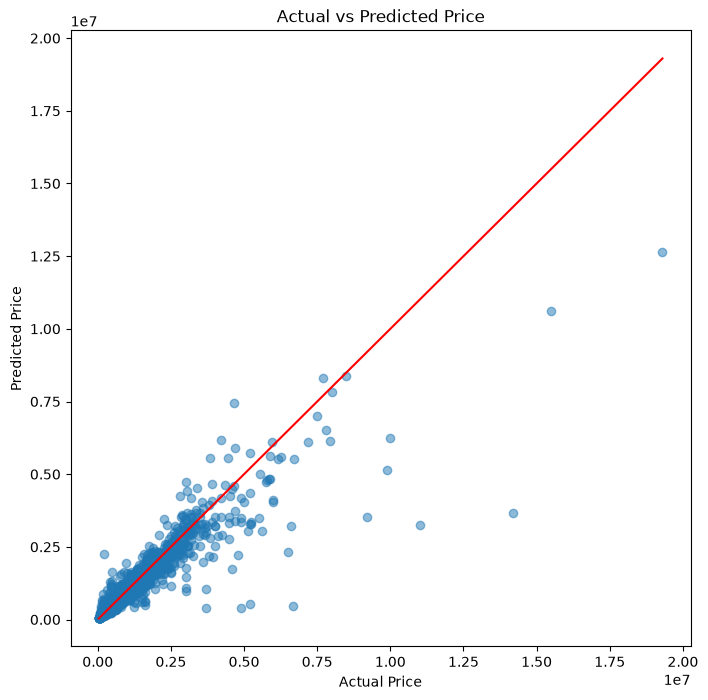

In [171]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(y_true, y_pred, alpha=0.5)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

In [172]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(best_xgb, "models/best_xgboost.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [173]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "models/feature_columns.pkl")

print(feature_columns)

['company', 'model', 'mileage', 'color', 'transmission', 'location', 'listing_age_days', 'air_conditioner', 'automatic', 'power_steering', 'remote_control', 'car_age']


In [174]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost",
        "CatBoost"
    ],
    "MAE_EGP": [
        344500.53,
        175015.00,
        130675.89,
        119622.59,
        119246.03,
        129672.11
    ],
    "RMSE_EGP": [
        825815.38,
        569046.33,
        467832.52,
        399400.78,
        385680.53,
        452268.86
    ],
    "R2_EGP": [
        0.2357,
        0.6371,
        0.7547,
        0.8212,
        0.8333,
        0.7708
    ]
})

results.sort_values("R2_EGP", ascending=False)

,Model,MAE_EGP,RMSE_EGP,R2_EGP
4,Tuned XGBoost,119246.03,385680.53,0.8333
3,XGBoost,119622.59,399400.78,0.8212
5,CatBoost,129672.11,452268.86,0.7708
2,Random Forest,130675.89,467832.52,0.7547
1,Decision Tree,175015.00,569046.33,0.6371
0,Linear Regression,344500.53,825815.38,0.2357


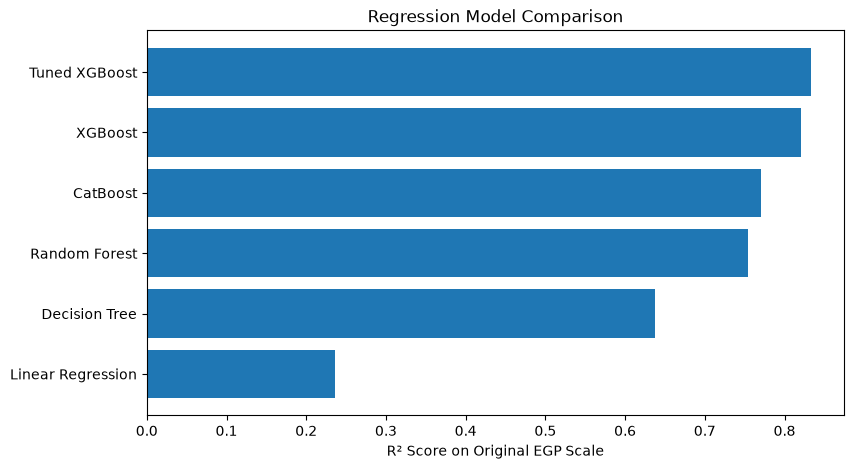

In [175]:
import matplotlib.pyplot as plt

comparison = results.sort_values("R2_EGP", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(comparison["Model"], comparison["R2_EGP"])
plt.xlabel("R² Score on Original EGP Scale")
plt.title("Regression Model Comparison")
plt.show()

In [176]:
import numpy as np
import pandas as pd
import joblib

model = joblib.load("models/best_xgboost.pkl")
preprocessor_loaded = joblib.load("models/preprocessor.pkl")
feature_columns = joblib.load("models/feature_columns.pkl")

def predict_car_price(car_data: dict) -> float:
    input_df = pd.DataFrame([car_data])

    input_df = input_df.reindex(columns=feature_columns)

    input_encoded = preprocessor_loaded.transform(input_df)

    predicted_log_price = model.predict(input_encoded)[0]

    predicted_price = np.expm1(predicted_log_price)

    return float(predicted_price)

In [177]:
sample_car = {
    "company": "Hyundai",
    "model": "Elantra",
    "mileage": 80000,
    "color": "White",
    "transmission": "Automatic",
    "location": "Cairo",
    "listing_age_days": 10,
    "air_conditioner": 1,
    "automatic": 1,
    "power_steering": 1,
    "remote_control": 1,
    "car_age": 5
}

predicted_price = predict_car_price(sample_car)

print(f"Predicted price: {predicted_price:,.0f} EGP")

Predicted price: 1,042,333 EGP


In [178]:
import os
import joblib

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the trained XGBoost model
joblib.dump(best_xgb, "models/best_xgboost.pkl")

# Save the preprocessing pipeline
joblib.dump(preprocessor, "models/preprocessor.pkl")

# Save the feature order
joblib.dump(X.columns.tolist(), "models/feature_columns.pkl")

print("✅ Everything saved successfully!")

✅ Everything saved successfully!


In [179]:
print(type(best_xgb))

<class 'xgboost.sklearn.XGBRegressor'>


In [180]:
print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [181]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(best_xgb, "models/best_xgboost.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(X.columns.tolist(), "models/feature_columns.pkl")

print("✅ Files saved successfully!")

✅ Files saved successfully!


In [182]:
import os

print(os.getcwd())
print(os.listdir("models"))

c:\Users\Asus\OneDrive\Desktop\ML_WORK\Used_Car_Price_Prediction\notebooks
['best_xgboost.pkl', 'feature_columns.pkl', 'preprocessor.pkl']
